In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [2]:
# Load data (reuse clean_description from Day 9, or rebuild it)
df = pd.read_csv("C:/Users/HP/Desktop/Internship Final Submission/NLP/2_raw_jobs.csv")
df = df.dropna(subset=["job_description"]).reset_index(drop=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s\+\#]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_description"] = df["job_description"].apply(clean_text)

In [3]:
# Helper to get top n-grams by frequency
def top_ngrams(corpus, ngram_range, top_n=20, max_features=2000):
    vec = CountVectorizer(
        ngram_range=ngram_range,
        stop_words="english",
        max_features=max_features
    )
    X = vec.fit_transform(corpus)
    counts = np.asarray(X.sum(axis=0)).flatten()
    terms = np.array(vec.get_feature_names_out())
    ranking = pd.DataFrame({"ngram": terms, "count": counts}).sort_values(
        "count", ascending=False
    ).reset_index(drop=True)
    return ranking.head(top_n)

Top unigrams:
                ngram  count
0       requirements   1201
1   responsibilities   1000
2            include   1000
3            support    801
4         experience    800
5              using    753
6        environment    571
7            product    507
8               team    492
9               join    492
10        management    457
11            strong    454
12            design    396
13             build    395
14              work    375
15            skills    360
16              data    358
17         financial    341
18          learning    338
19            impact    318

Top bigrams:
                        ngram  count
0   responsibilities include   1000
1                impact fast    270
2                make impact    270
3                 fast paced    270
4          great opportunity    270
5           opportunity make    270
6          paced environment    270
7           seeking talented    264
8   results responsibilities    264
9      passionate deli

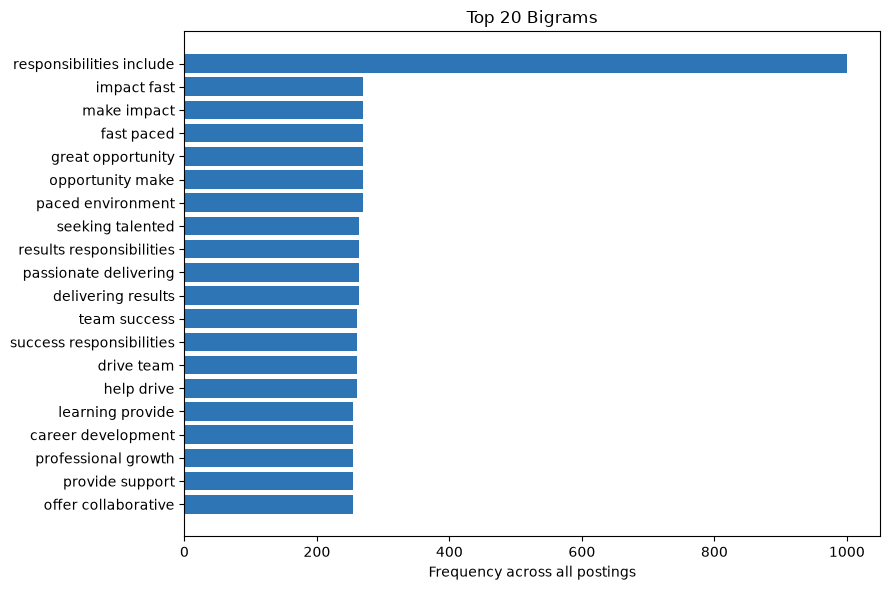

In [4]:
# Unigrams, bigrams, trigrams
top_unigrams = top_ngrams(df["clean_description"], (1, 1))
top_bigrams = top_ngrams(df["clean_description"], (2, 2))
top_trigrams = top_ngrams(df["clean_description"], (3, 3))

print("Top unigrams:\n", top_unigrams)
print("\nTop bigrams:\n", top_bigrams)
print("\nTop trigrams:\n", top_trigrams)

# Combined n-grams (1 to 3) via TF-IDF, as in the task example
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words="english",
    max_features=1000
)
X = vectorizer.fit_transform(df["clean_description"])
feature_names = np.array(vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(X.mean(axis=0)).flatten()

combined_ranking = pd.DataFrame({
    "ngram": feature_names,
    "avg_tfidf_score": mean_tfidf
}).sort_values("avg_tfidf_score", ascending=False).reset_index(drop=True)

print(combined_ranking.head(30))

# Check known multi-word skills
known_multiword_skills = [
    "machine learning", "deep learning", "power bi", "natural language processing",
    "data analysis", "computer vision", "cloud computing",
]

bigram_vec = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=5000)
bigram_vec.fit(df["clean_description"])
bigram_vocab = set(bigram_vec.get_feature_names_out())

trigram_vec = CountVectorizer(ngram_range=(3, 3), stop_words="english", max_features=5000)
trigram_vec.fit(df["clean_description"])
trigram_vocab = set(trigram_vec.get_feature_names_out())

for skill in known_multiword_skills:
    print(skill, "-> bigram:", skill in bigram_vocab, "| trigram:", skill in trigram_vocab)

# Plot top bigrams
plt.figure(figsize=(9, 6))
plt.barh(top_bigrams["ngram"][::-1], top_bigrams["count"][::-1], color="#2E75B6")
plt.xlabel("Frequency across all postings")
plt.title("Top 20 Bigrams")
plt.tight_layout()
plt.show()